# ЛР2. DCGAN на Fashion-MNIST: математика, интерпретация, устойчивость

Сквозной проход по работе через вызовы пакета `gan_robustness`. Тяжёлые вычисления (обучение классификатора и четырёх DCGAN, метрики, интерпретация) выполняются командой `make all`; здесь — лёгкие живые вызовы и готовые таблицы/рисунки из `reports/`.

In [1]:
import json
from pathlib import Path

import pandas as pd
import torch
from IPython.display import Image, display

from gan_robustness.config import load_config

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIG = ROOT / 'reports' / 'figures'
TAB = ROOT / 'reports' / 'tables'
config = load_config(ROOT / 'configs' / 'base.yaml')
print('latent', config.model.latent_dim, '| g_base', config.model.g_base,
      '| subsample', config.data.subsample_size)

latent 100 | g_base 48 | subsample 30000


## Часть 1. Задача и данные

Fashion-MNIST: 60k train (10 сбалансированных классов) + 10k test, 1 канал 28×28, вход в [-1, 1]. Проверка качества чистая.

,check,count
0,train_duplicates,0
1,train_test_overlap,0
2,label_conflicts,0
3,out_of_range,0
4,degenerate,0


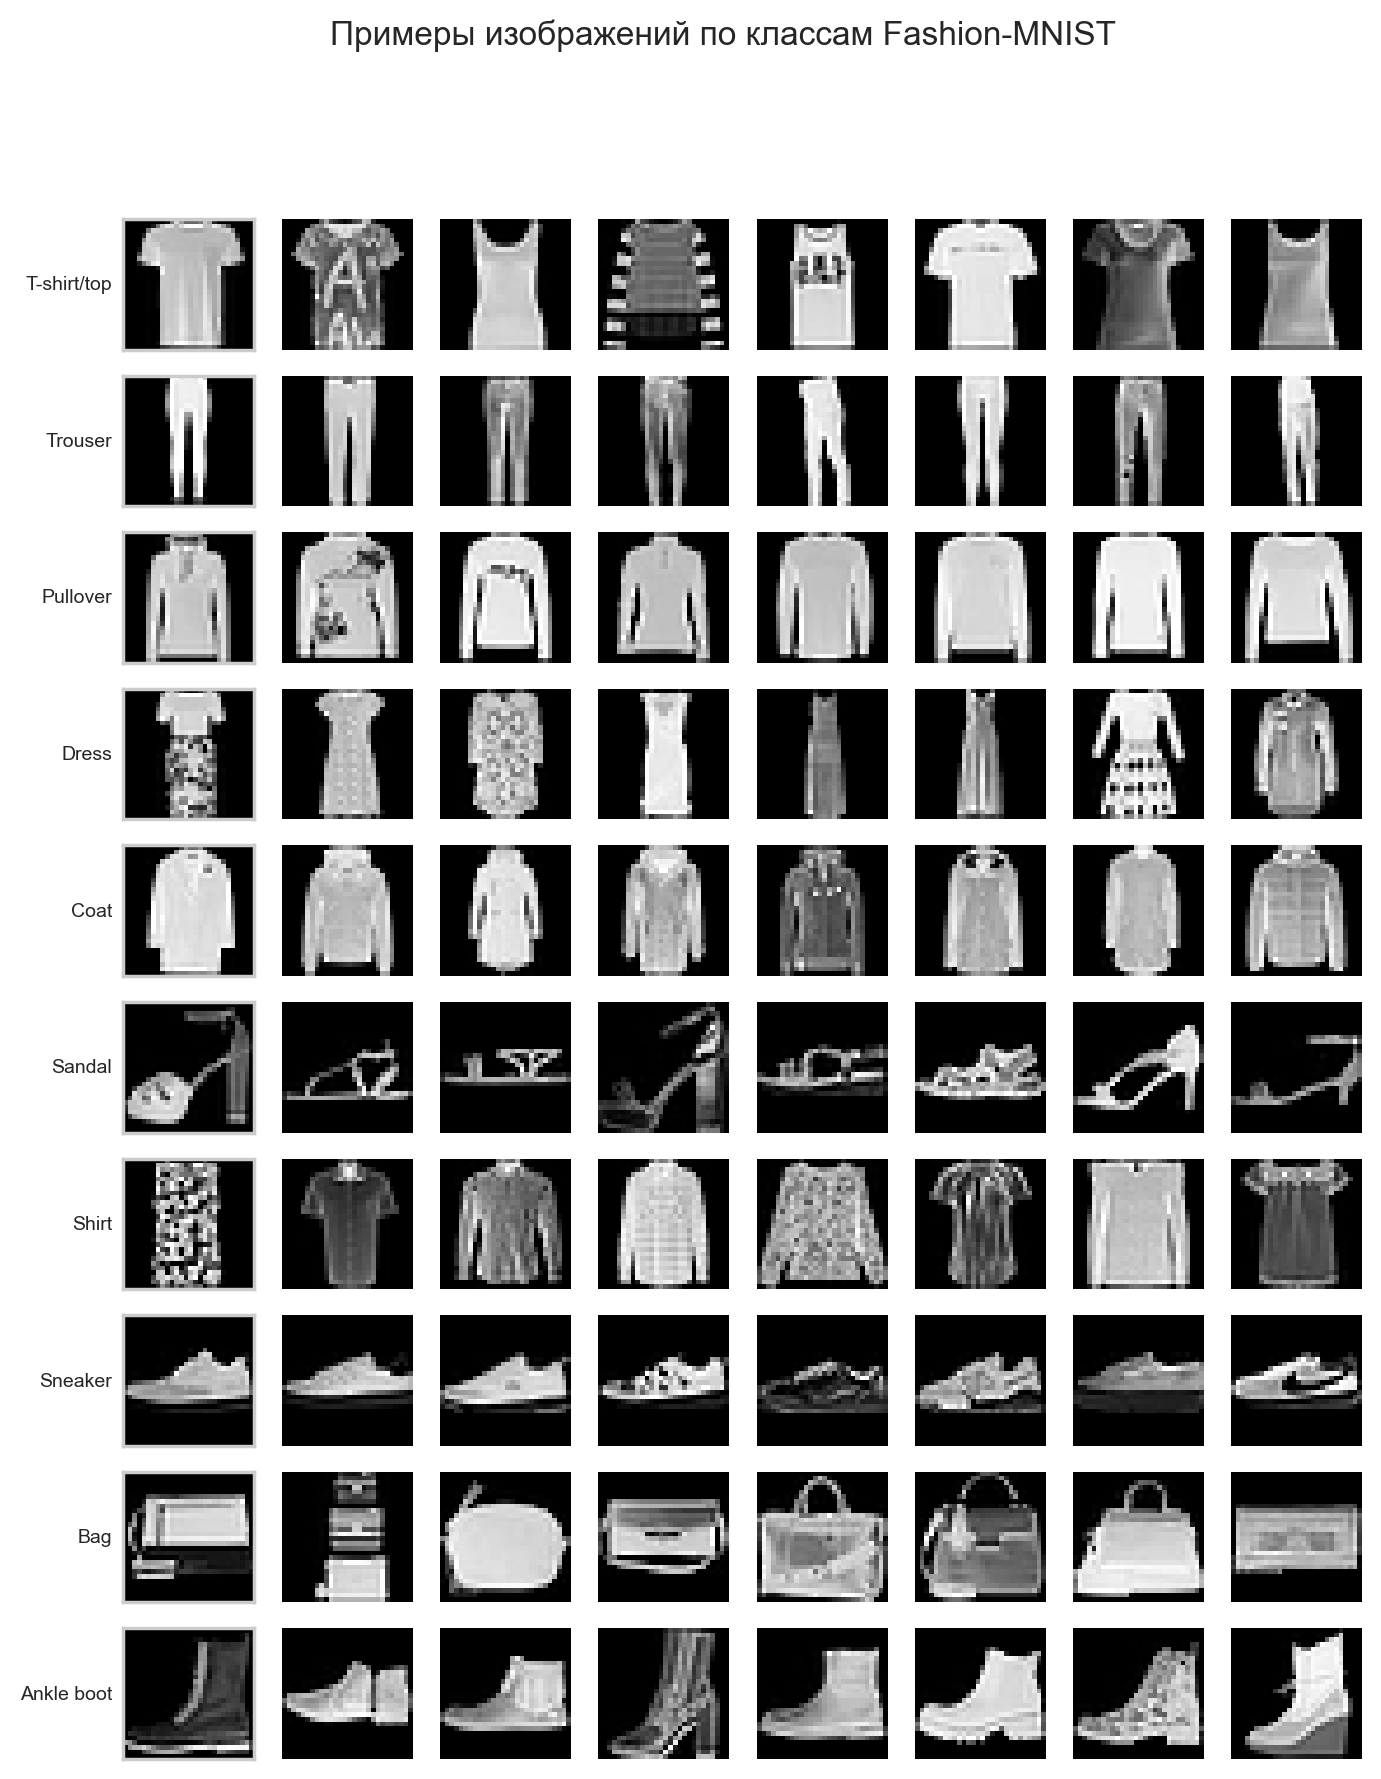

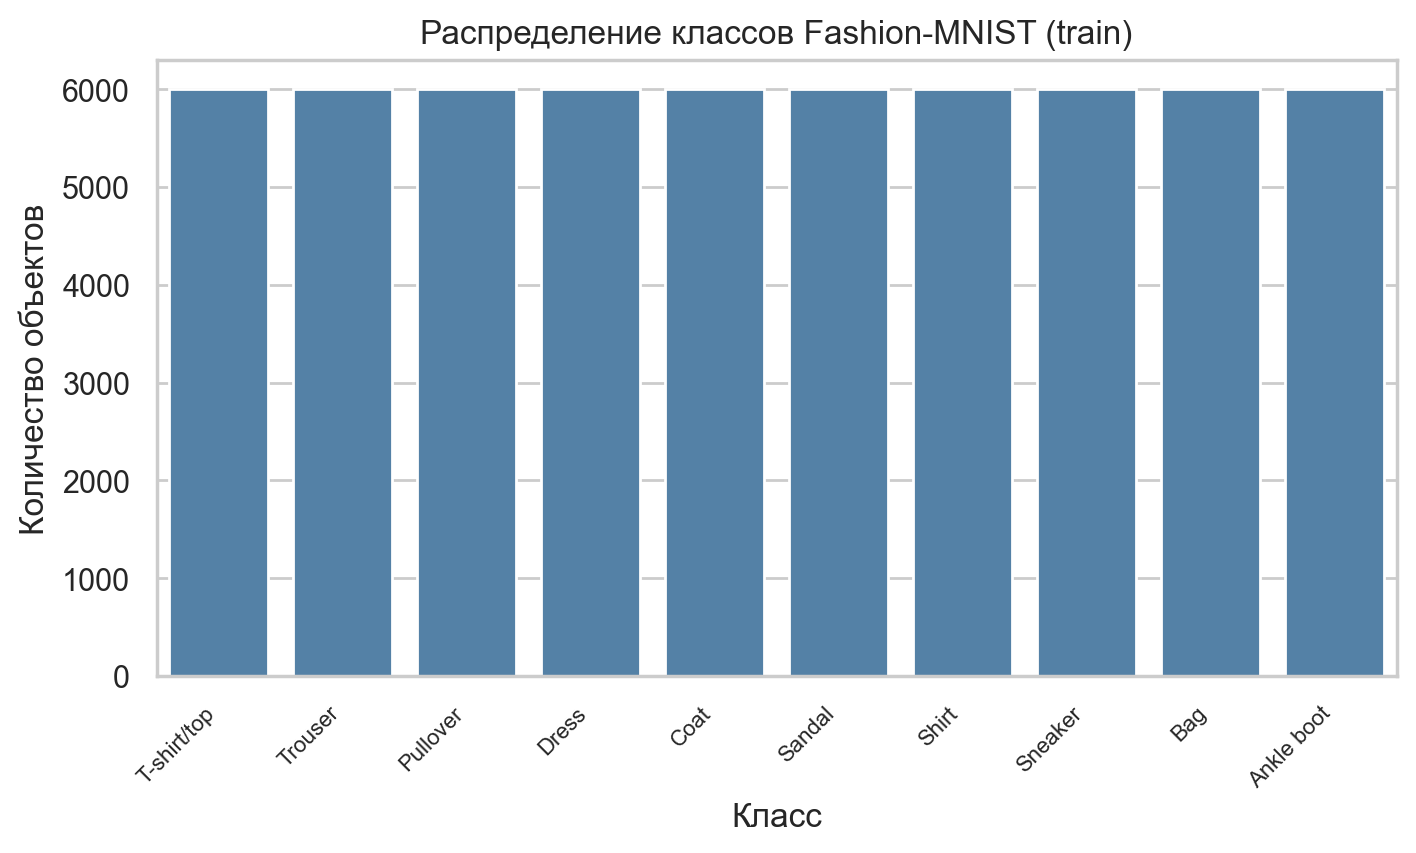

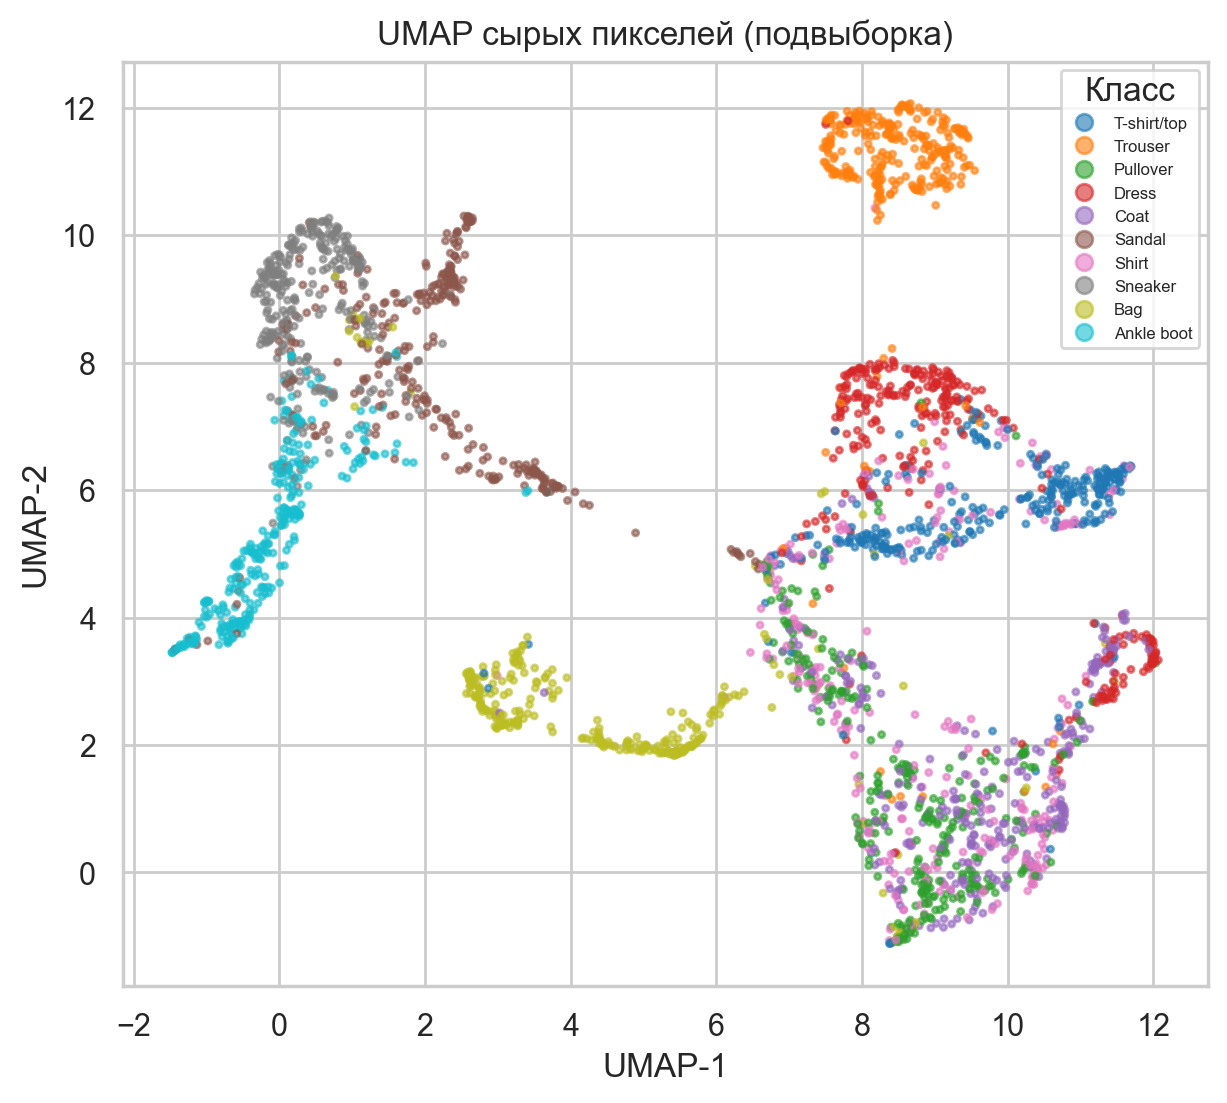

In [2]:
display(pd.read_csv(TAB / 'part1_quality.csv'))
for name in ['part1_examples', 'part1_class_histogram', 'part1_umap_pixels']:
    display(Image(str(FIG / f'{name}.png')))

## Часть 2. Математика и архитектура DCGAN

Минимаксная игра, оптимальный дискриминатор $D^*(x)=p_{data}/(p_{data}+p_g)$, несатурирующая потеря генератора. Число параметров — живой вызов `summarize_model`.

In [3]:
from gan_robustness.models.generator import Generator
from gan_robustness.models.discriminator import Discriminator
from gan_robustness.models.summary import summarize_model

g = Generator(config.model.latent_dim, config.model.g_base)
d = Discriminator(config.model.d_base)
display(summarize_model(g, 'Генератор'))
display(summarize_model(d, 'Дискриминатор'))

,model,layer,type,parameters
0,Генератор,net.0,ConvTranspose2d,470496
1,Генератор,net.1,BatchNorm2d,192
2,Генератор,net.3,ConvTranspose2d,73776
3,Генератор,net.4,BatchNorm2d,96
4,Генератор,net.6,ConvTranspose2d,769
5,Генератор,TOTAL,,545329


,model,layer,type,parameters
0,Дискриминатор,features_net.0,Conv2d,816
1,Дискриминатор,features_net.2,Conv2d,73824
2,Дискриминатор,features_net.3,BatchNorm2d,192
3,Дискриминатор,classifier,Conv2d,4705
4,Дискриминатор,TOTAL,,79537


## Часть 3. Базовое обучение и оценка

Живая генерация из обученного генератора, затем сводные метрики и рисунки.

In [4]:
from gan_robustness.training.checkpoint import load_gan
from gan_robustness.evaluation.generate import generate_float, to_uint8
from gan_robustness.visualization.gan_viz import tile_grid
import matplotlib.pyplot as plt

device = torch.device('cpu')
g_base, d_base = load_gan(ROOT / 'artifacts' / 'models' / 'baseline.pt', device)
sample = to_uint8(generate_float(g_base, 36, config.model.latent_dim, device, 0))
plt.figure(figsize=(5, 5)); plt.imshow(tile_grid(sample), cmap='gray'); plt.axis('off')
plt.title('Живая генерация (базовая модель)'); plt.show()

/var/folders/qy/dbkxn3jn7_j3y6cnv7kkm8ph0000gn/T/ipykernel_93949/1857124201.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.title('Живая генерация (базовая модель)'); plt.show()


,scenario,domain_fid,precision,recall,class_js_divergence,dropped_classes,mean_confidence,low_confidence_fraction,diversity,gen_nn_median,test_nn_median,seconds_per_epoch,trigger_rate,epsilon
0,baseline,39.460,0.4369,0.5684,0.0143,0,0.7414,0.2972,26.715,5.431,3.612,52.3,NaN,NaN
1,imbalance,116.922,0.4903,0.3478,0.0791,1,0.7274,0.3150,24.105,4.876,3.759,69.4,NaN,NaN
2,poison_eps0.05,38.108,0.4312,0.5831,0.0090,0,0.7418,0.3006,26.818,5.480,3.612,60.7,0.0000,0.05
3,poison_eps0.2,41.731,0.4258,0.5676,0.0083,0,0.7367,0.3057,26.537,5.410,3.615,45.5,0.0205,0.20


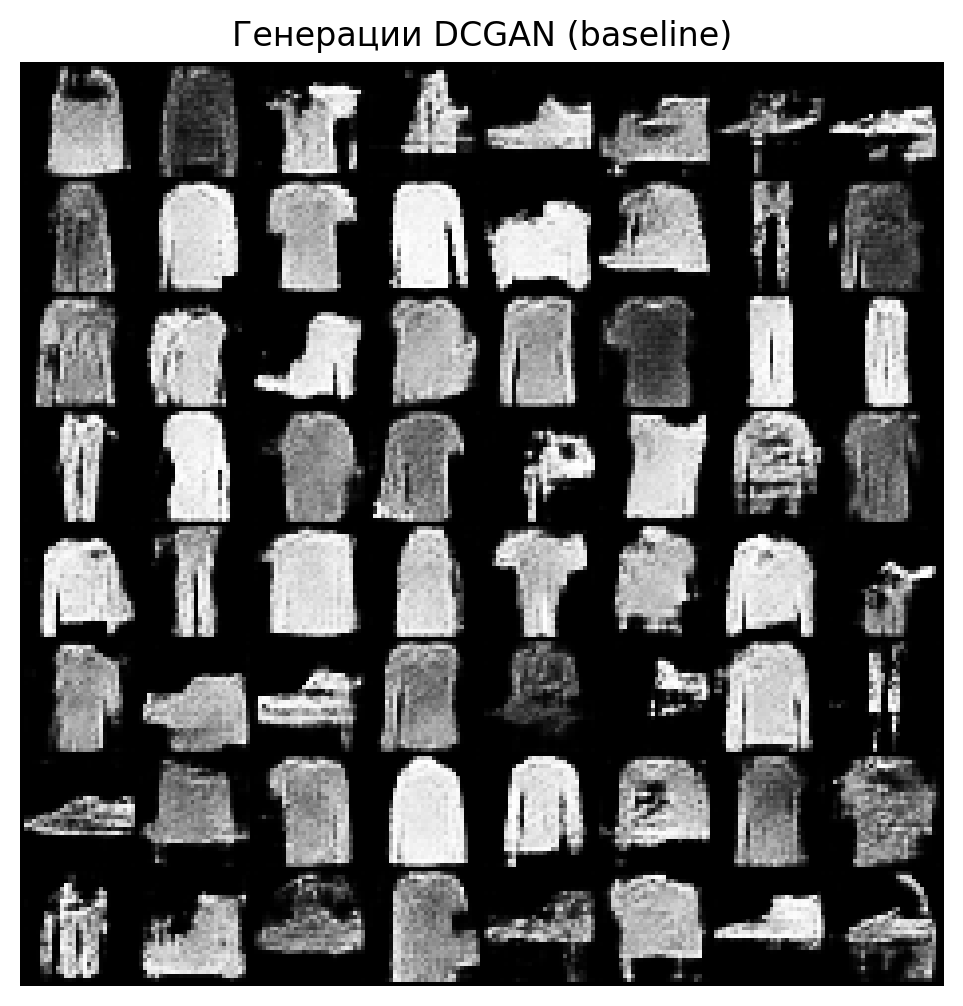

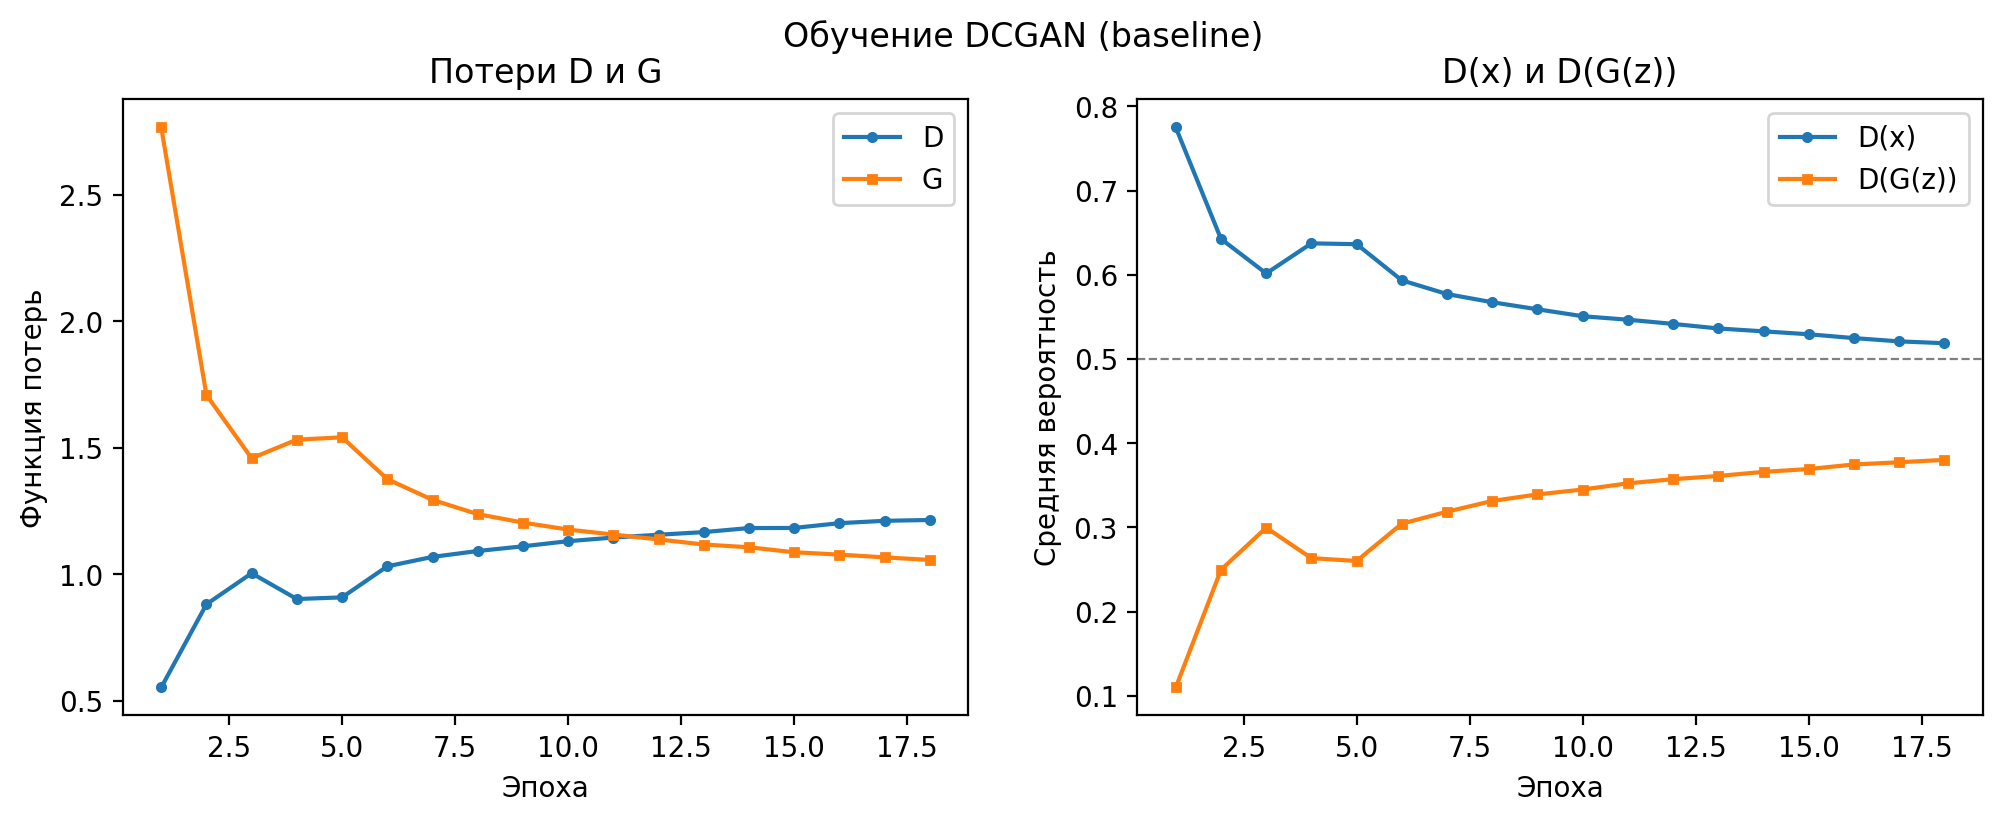

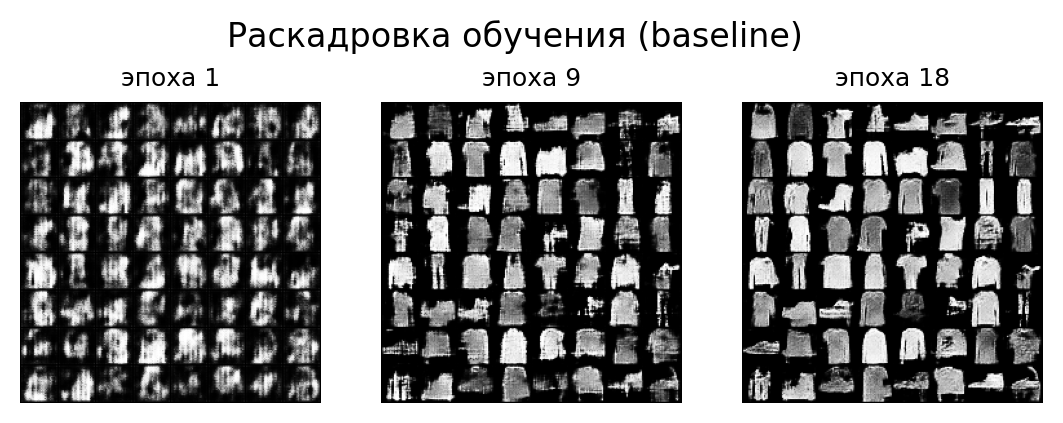

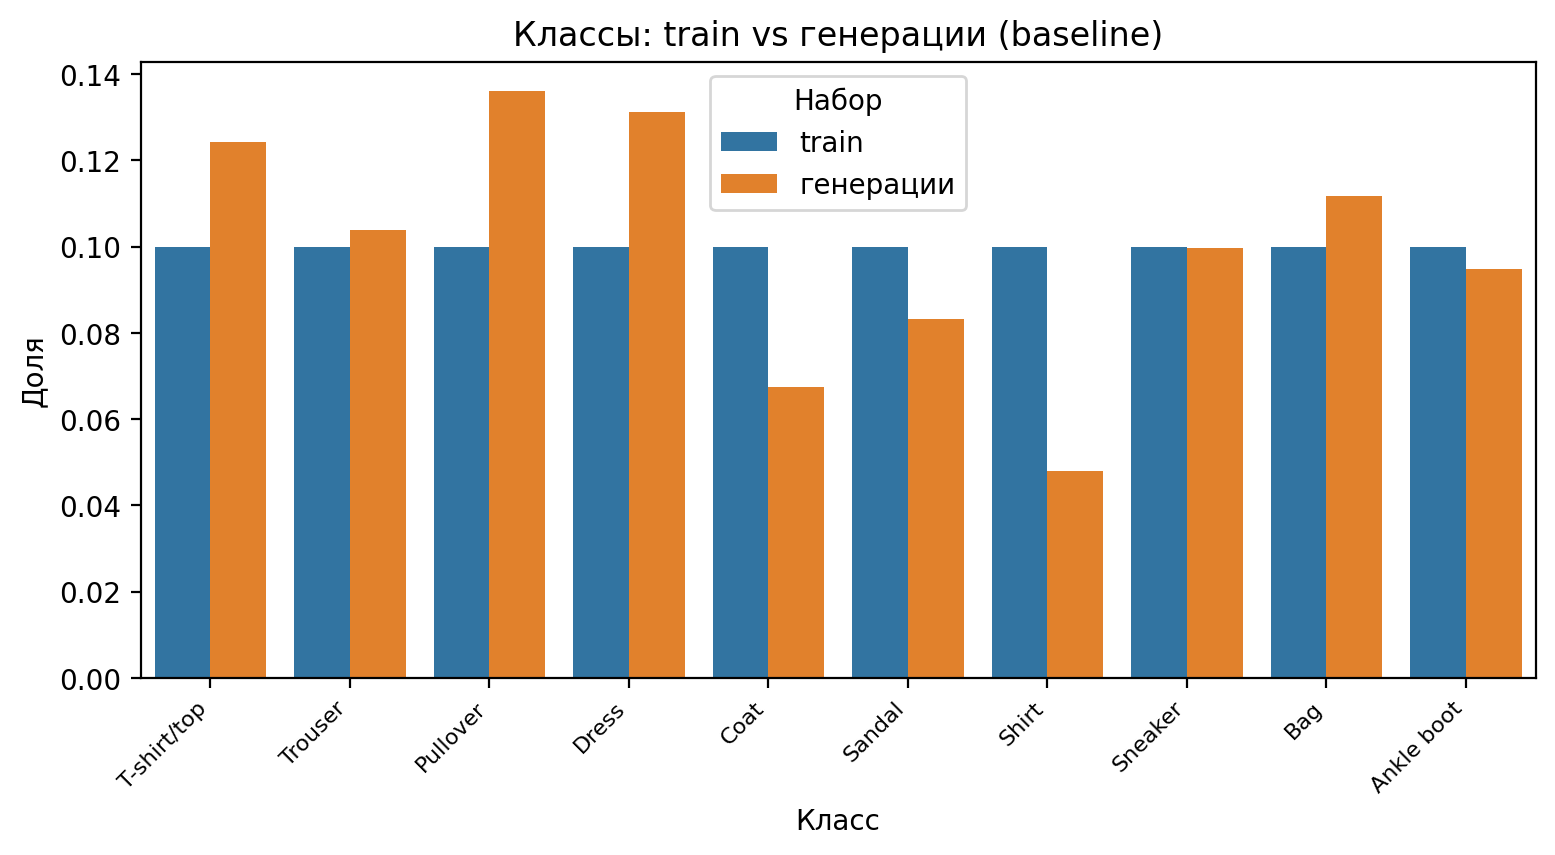

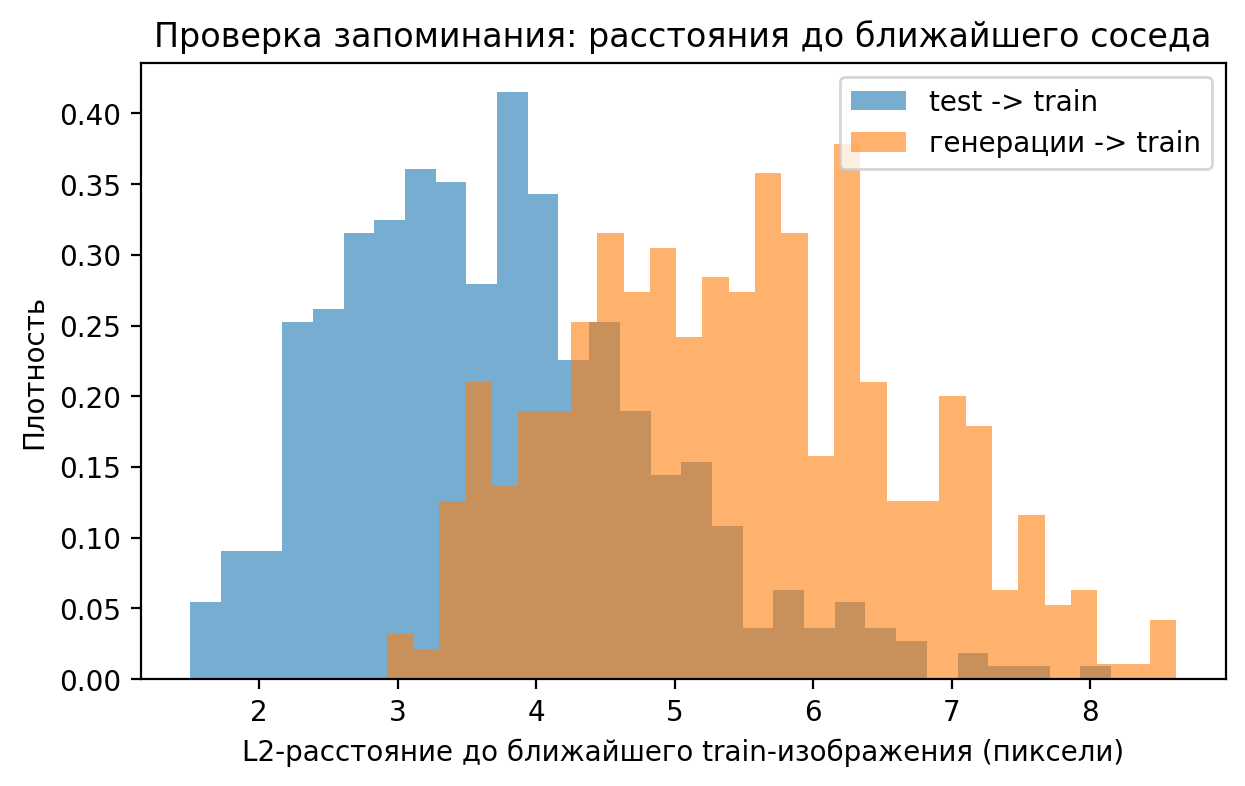

In [5]:
display(pd.read_csv(TAB / 'metrics_summary.csv'))
for name in ['part3_samples_baseline', 'part3_loss_baseline',
             'part3_storyboard_baseline', 'part3_classdist_baseline',
             'part3_memorization_baseline']:
    p = FIG / f'{name}.png'
    if p.exists():
        display(Image(str(p)))

Базовая модель даёт узнаваемую одежду; D(x) и D(G(z)) держатся около устойчивого равновесия. Проверка запоминания: генерации не ближе к train, чем реальные тестовые объекты.

## Часть 4. Нарушение данных: дисбаланс и отравление

Вариант A — удаление 95% трёх классов (выпадение мод); Вариант B — триггер 4×4.

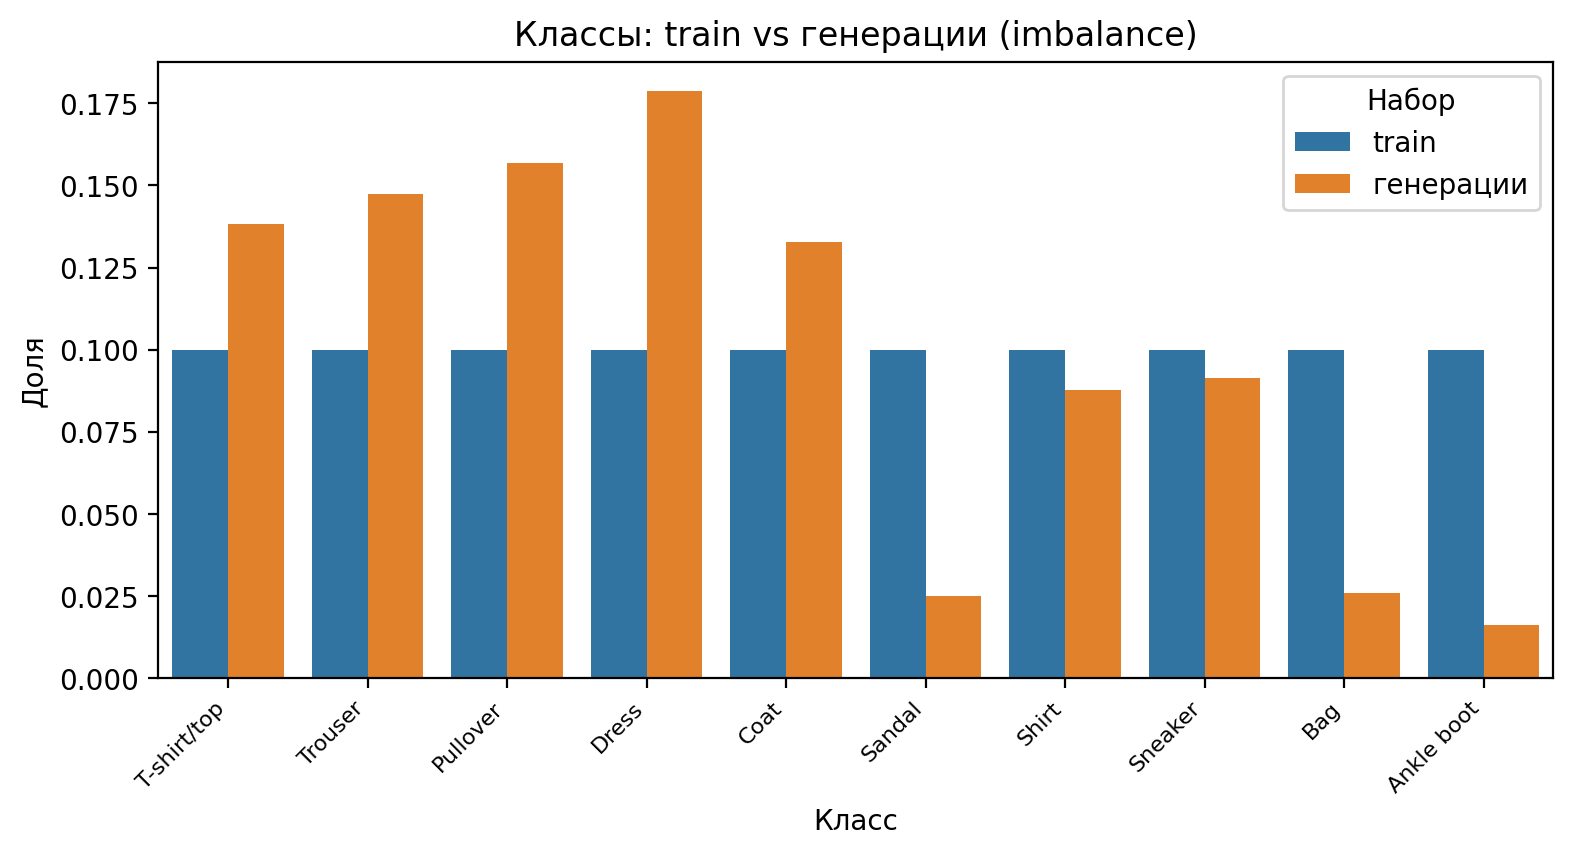

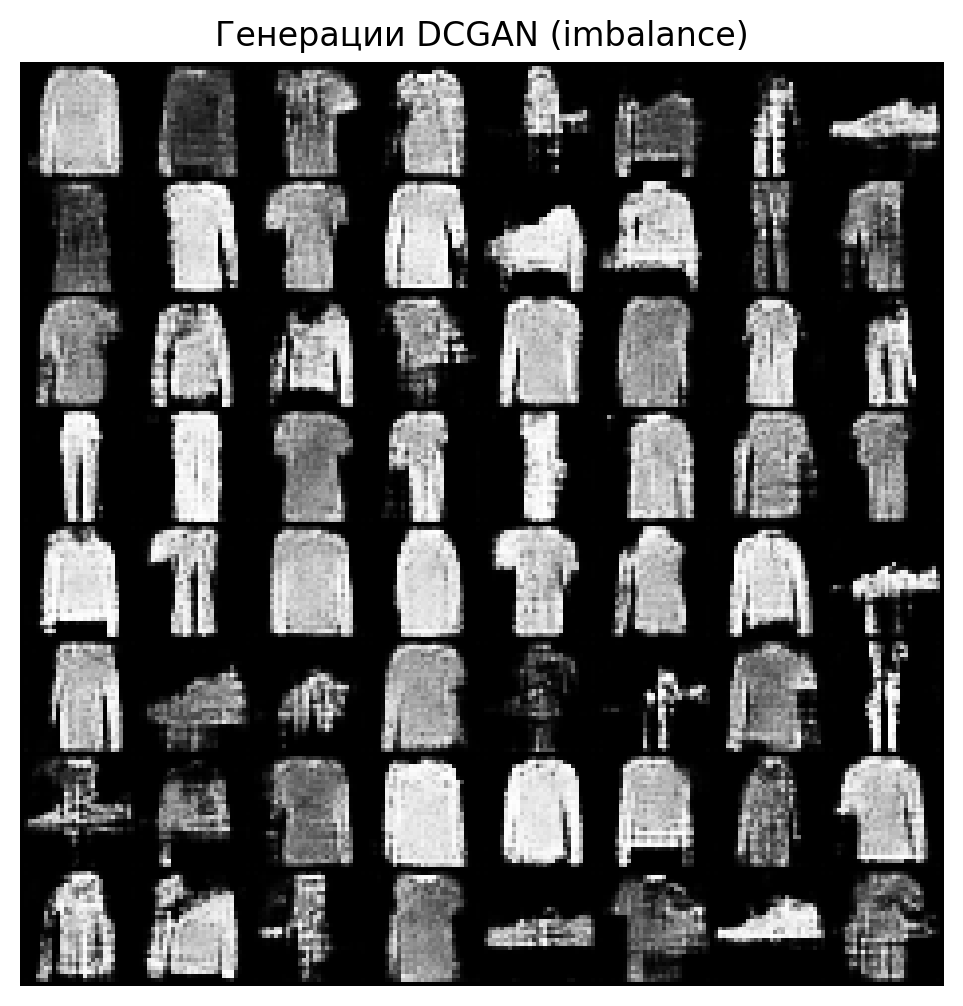

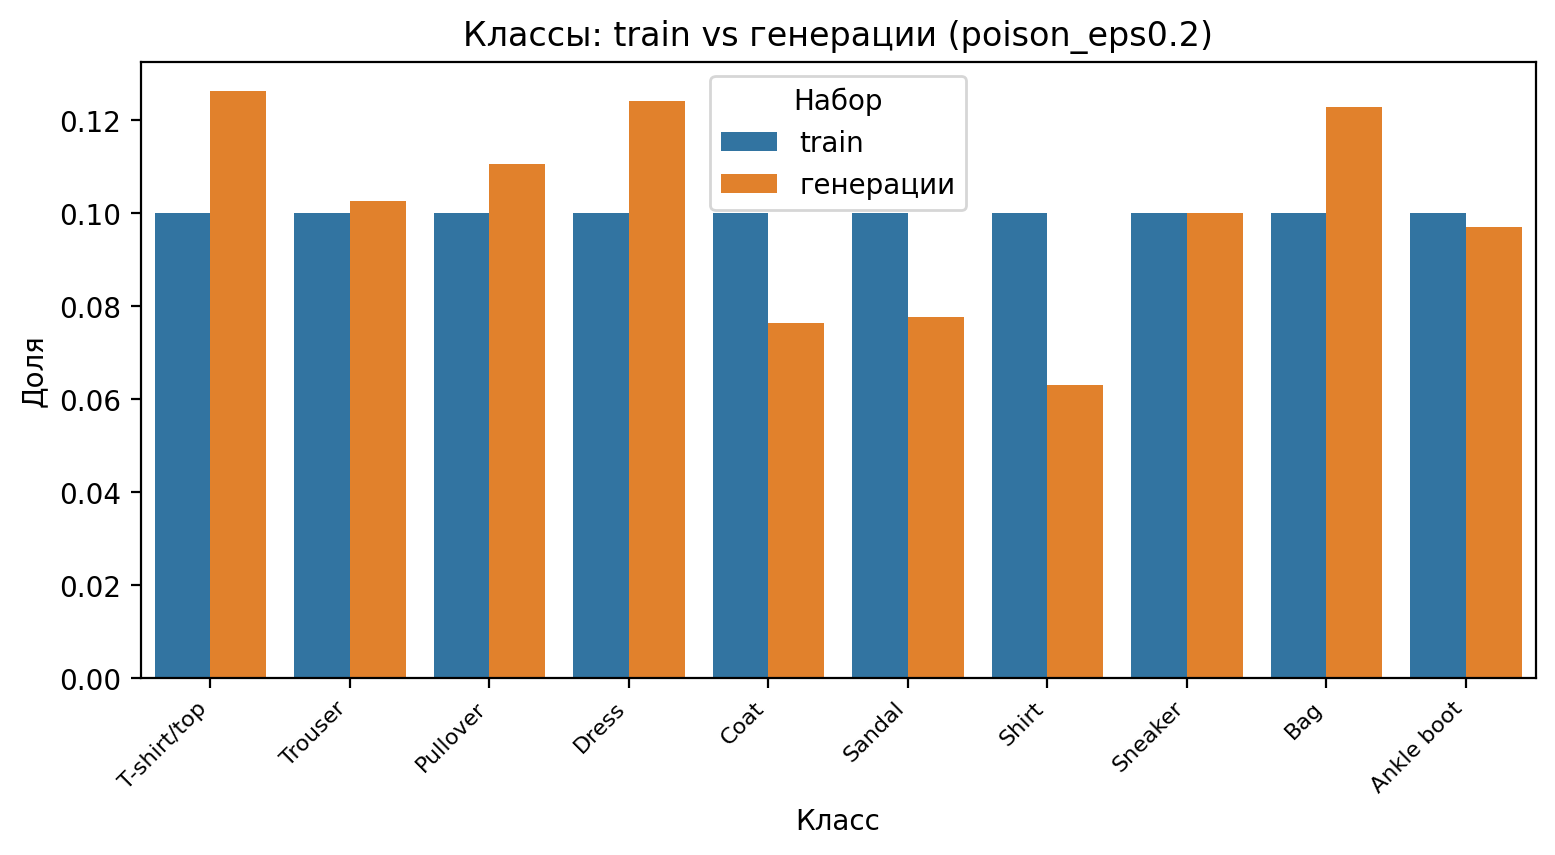

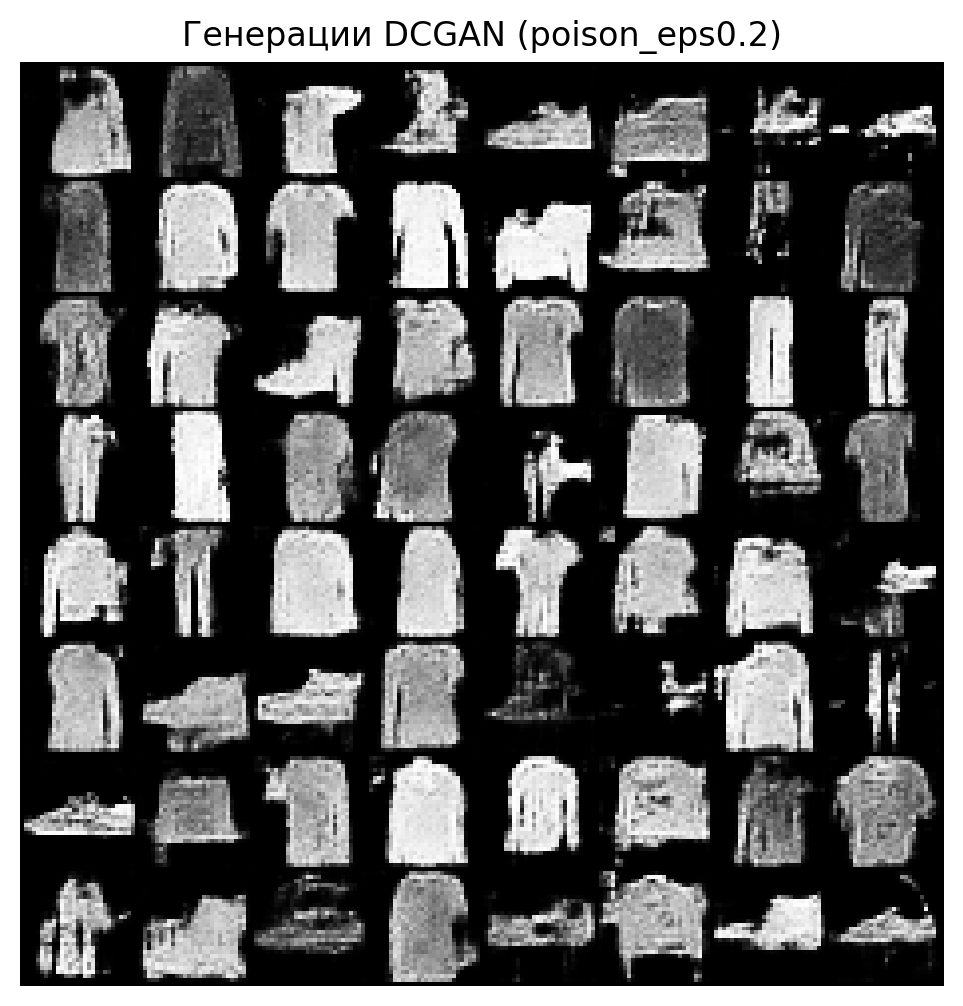

In [6]:
for name in ['part3_classdist_imbalance', 'part3_samples_imbalance',
             'part3_classdist_poison_eps0.2', 'part3_samples_poison_eps0.2']:
    p = FIG / f'{name}.png'
    if p.exists():
        display(Image(str(p)))

При дисбалансе падает recall и доля редких классов в генерациях при сохранении precision (реалистичность). При отравлении часть генераций воспроизводит триггер (см. столбец trigger_rate в сводной таблице).

## Часть 5. Интерпретация

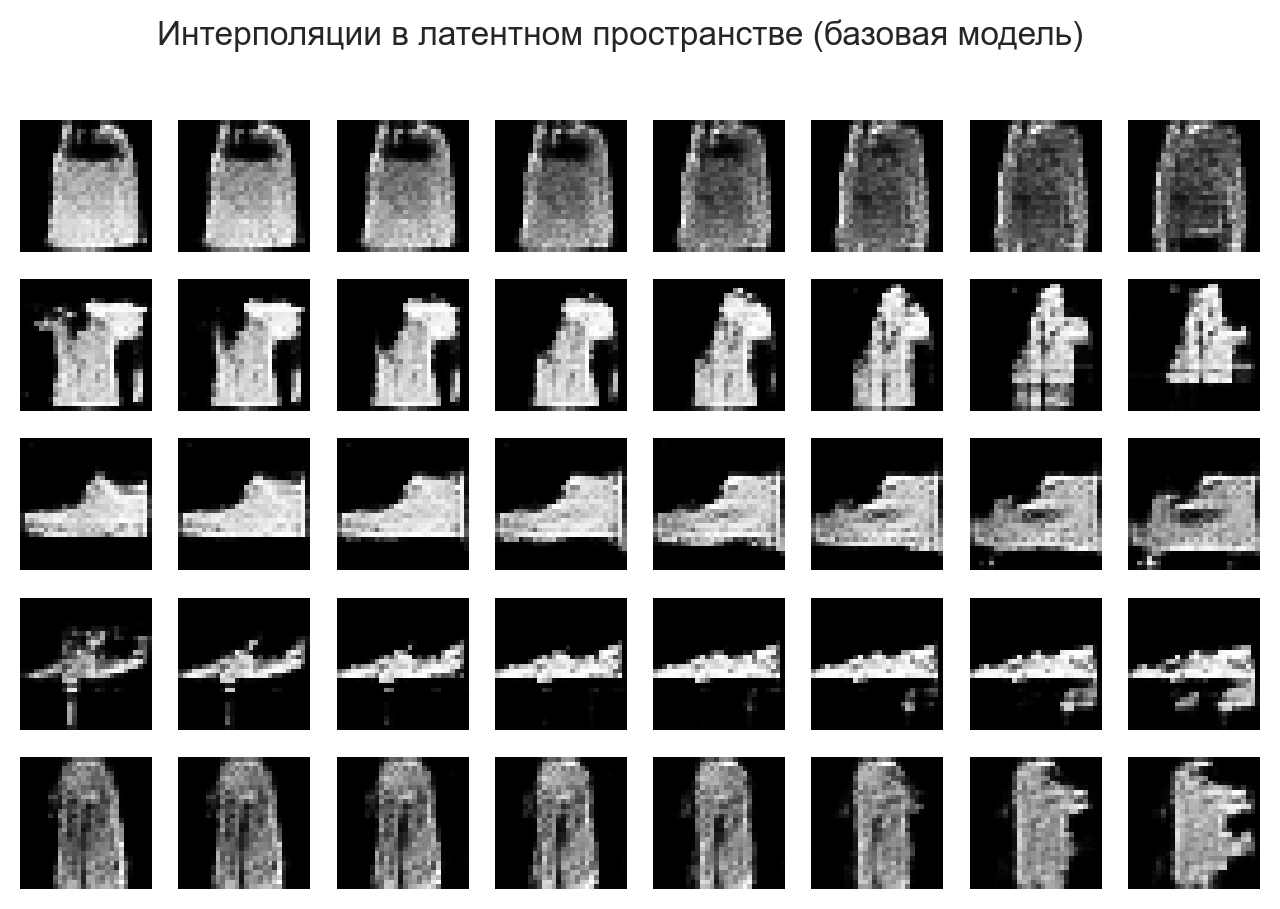

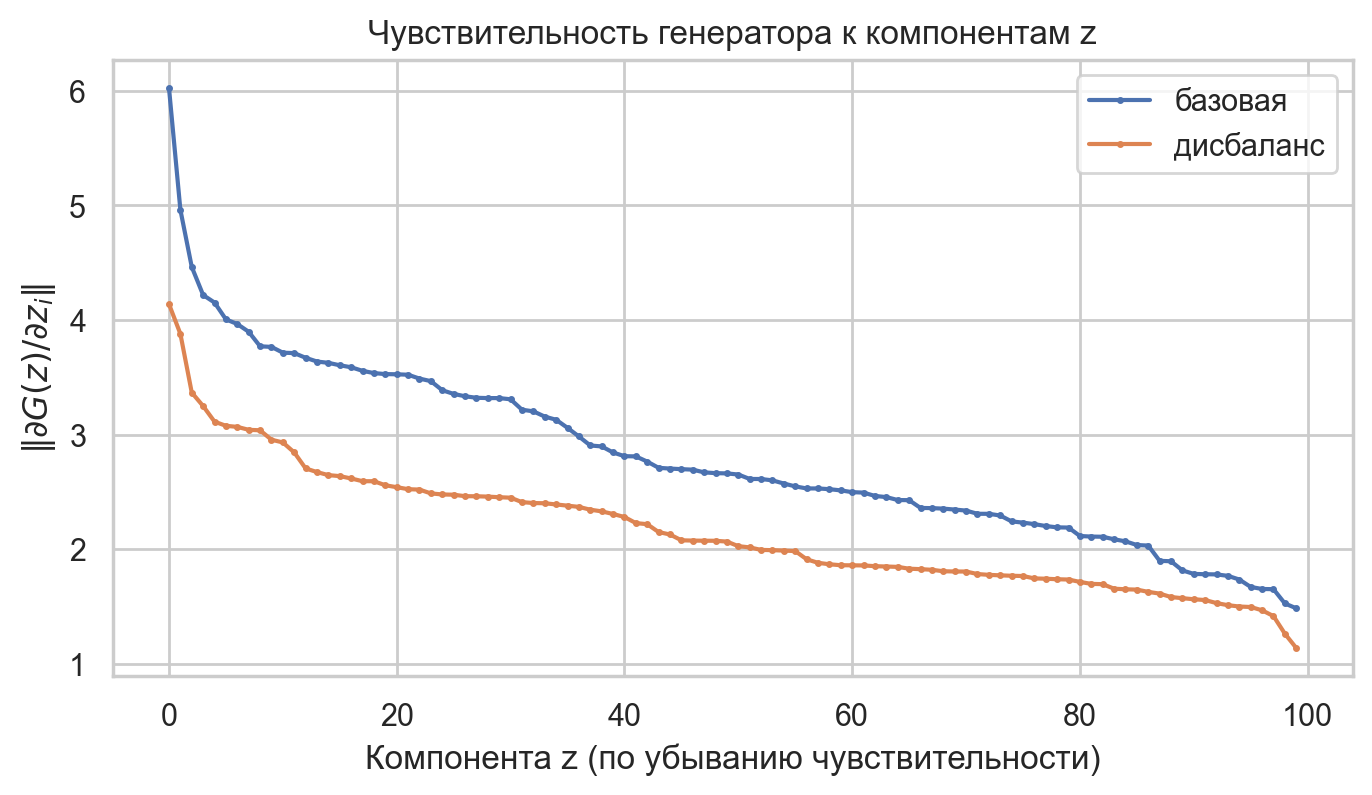

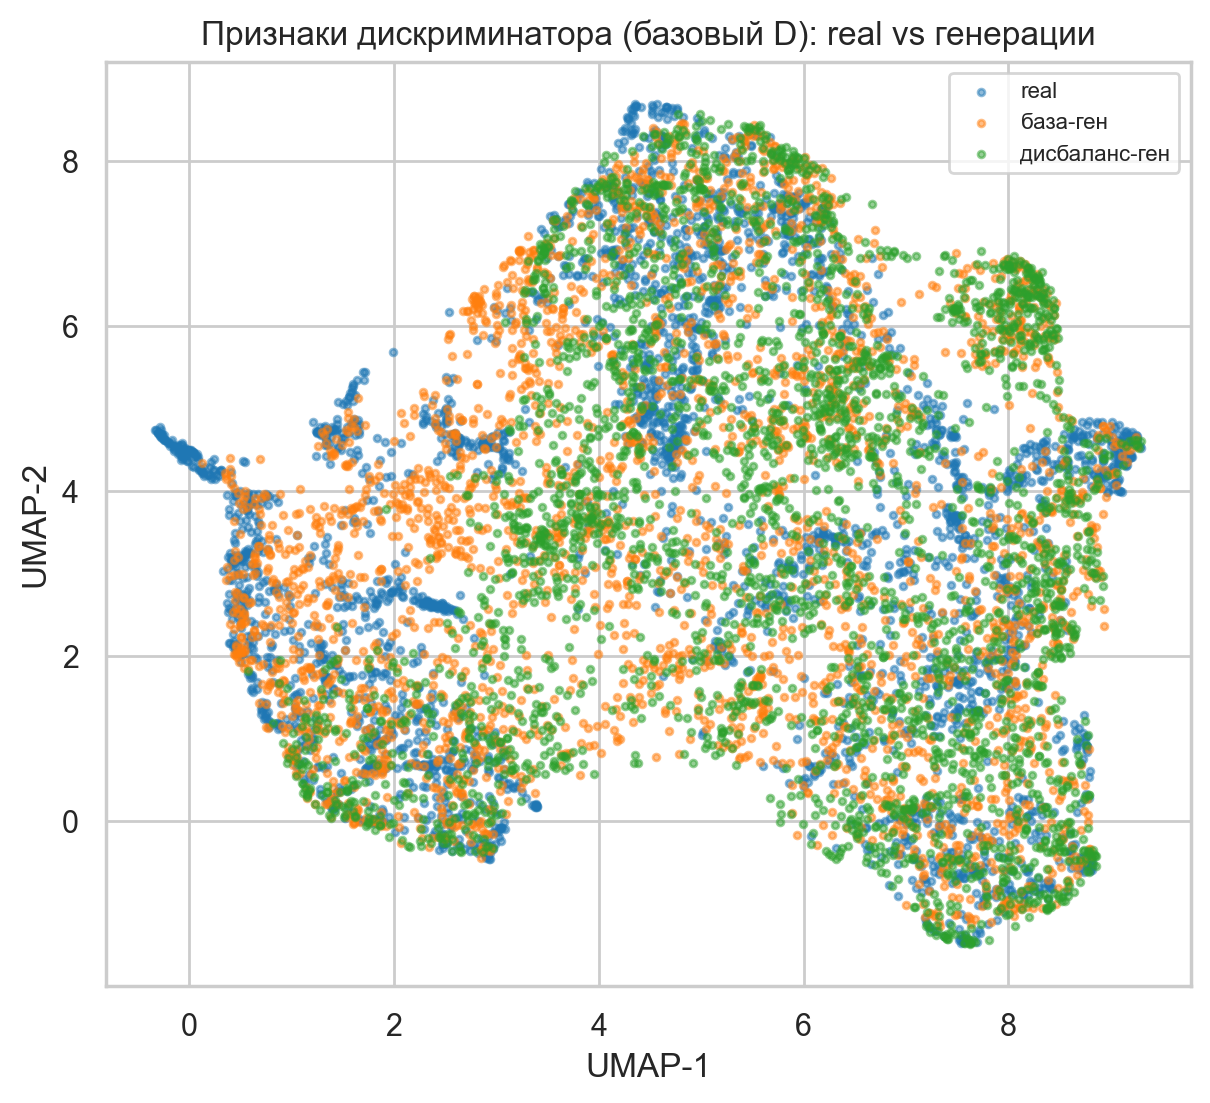

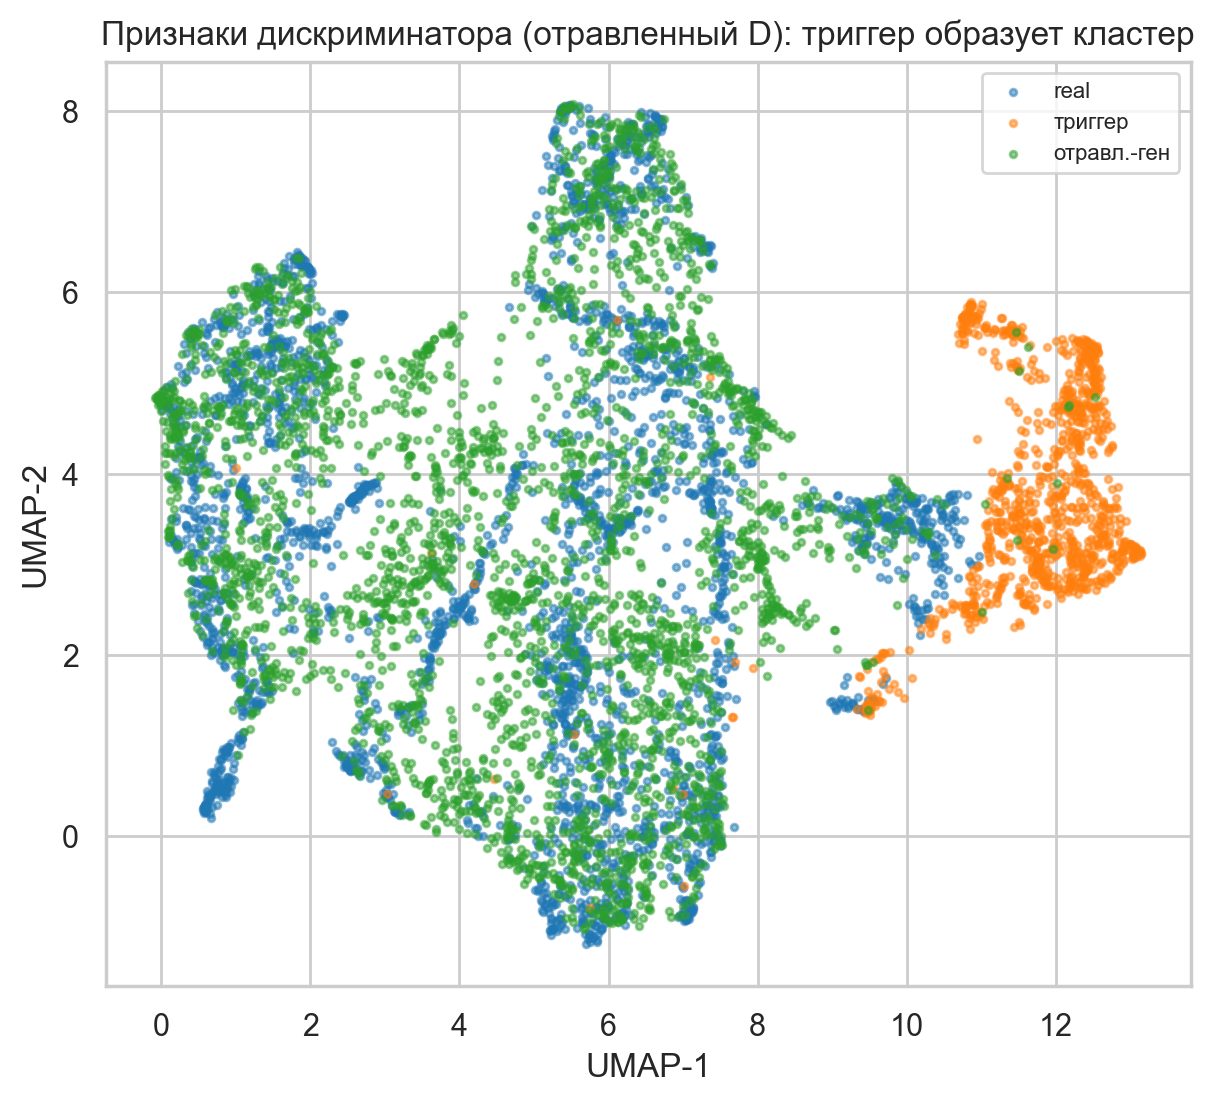

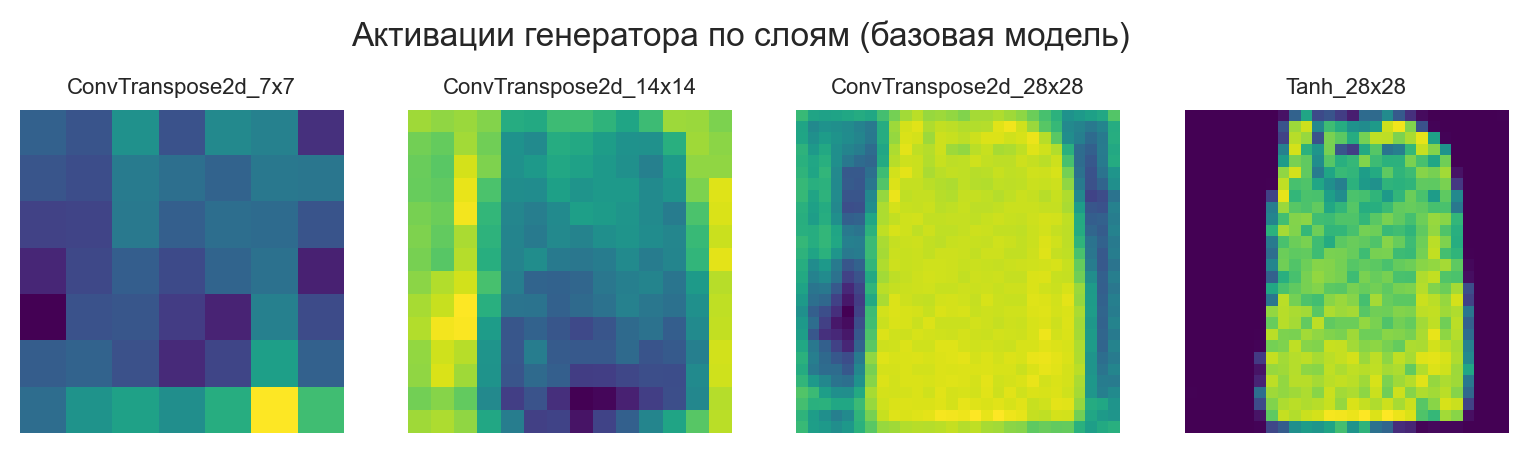

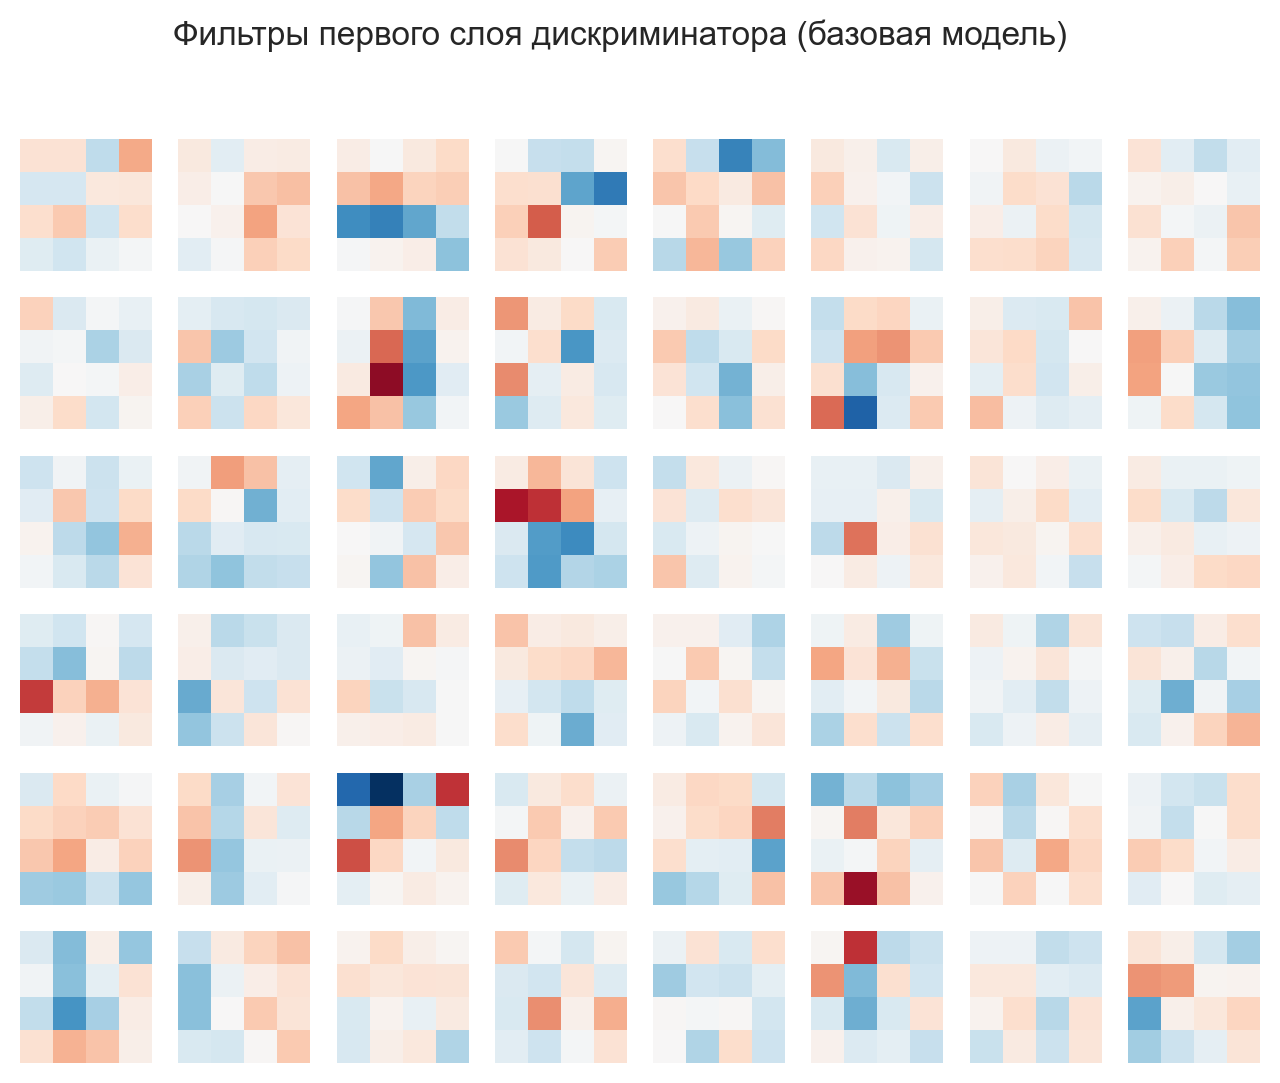

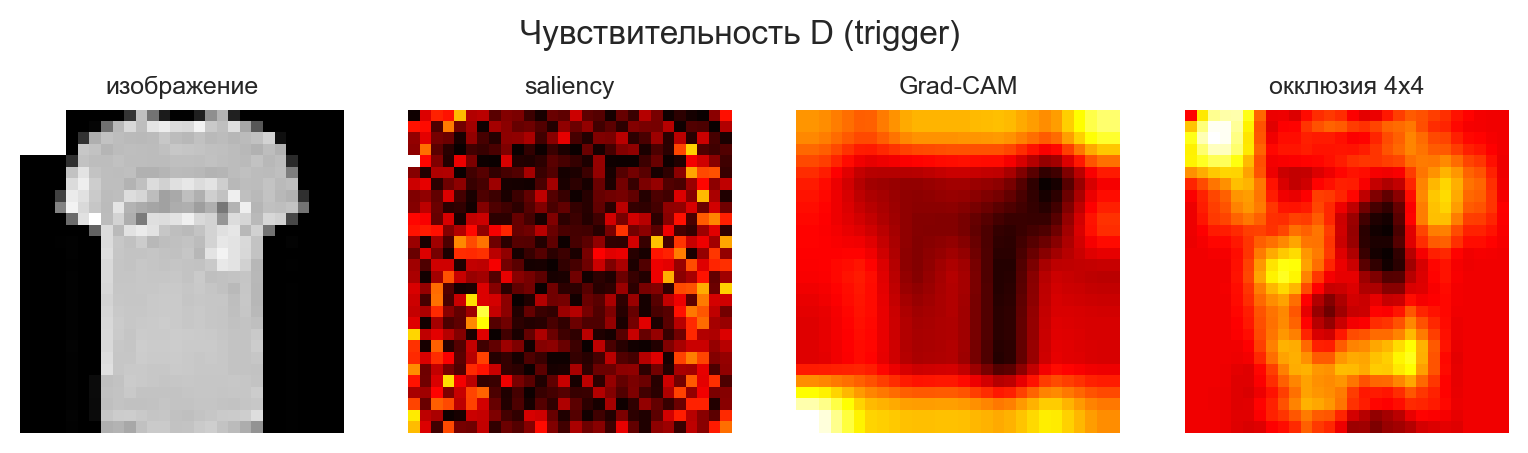

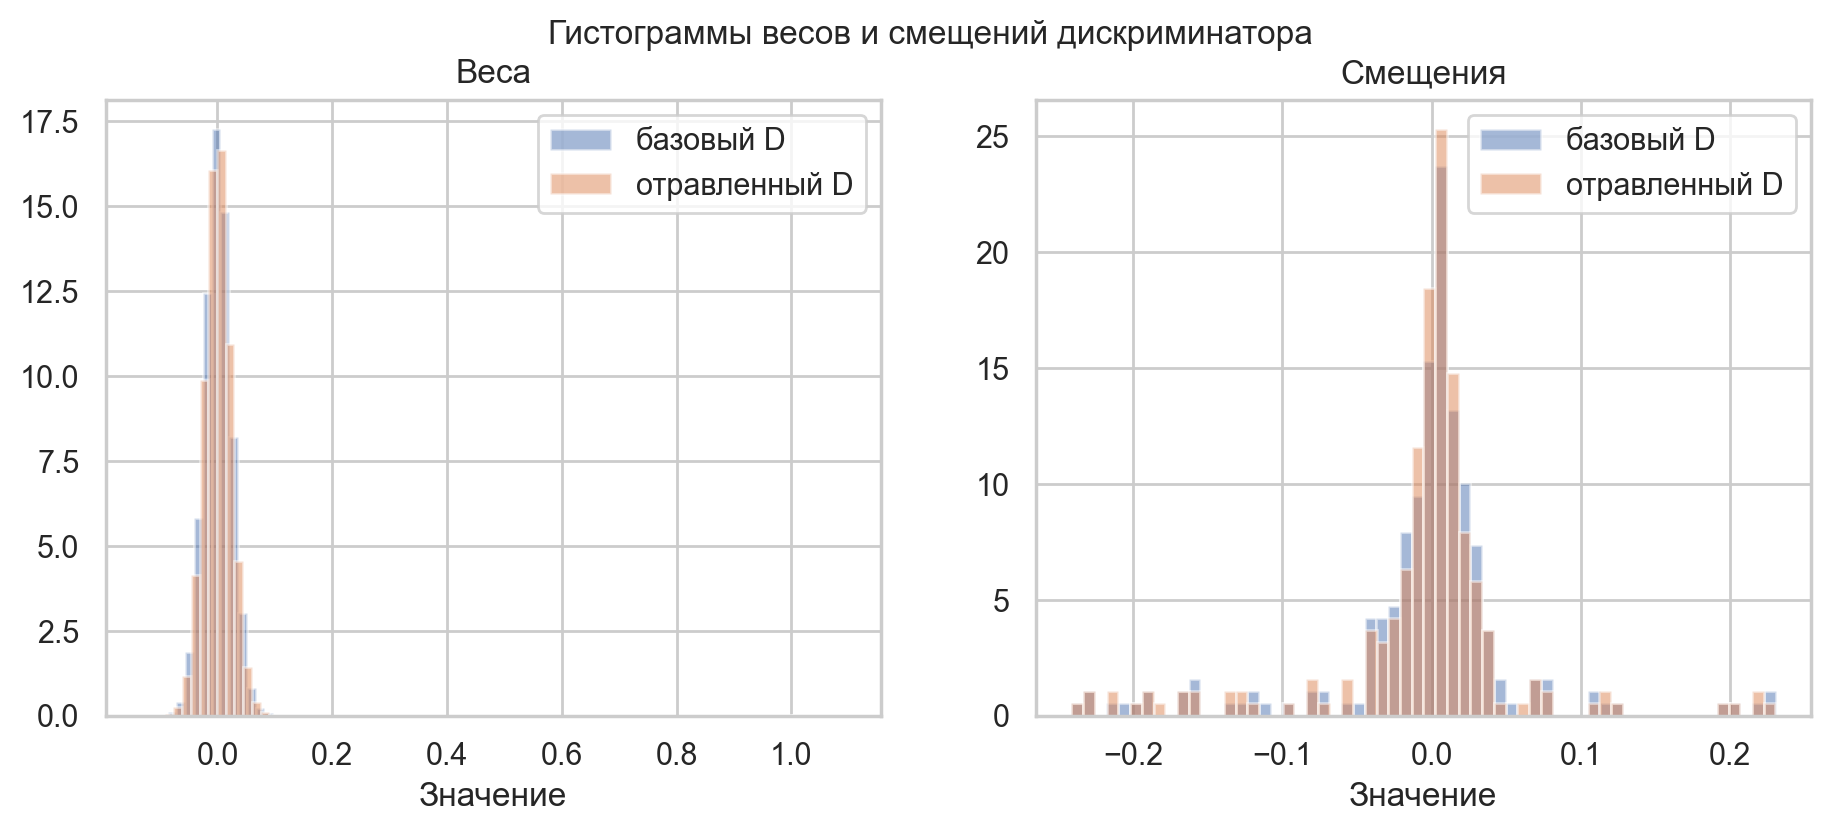

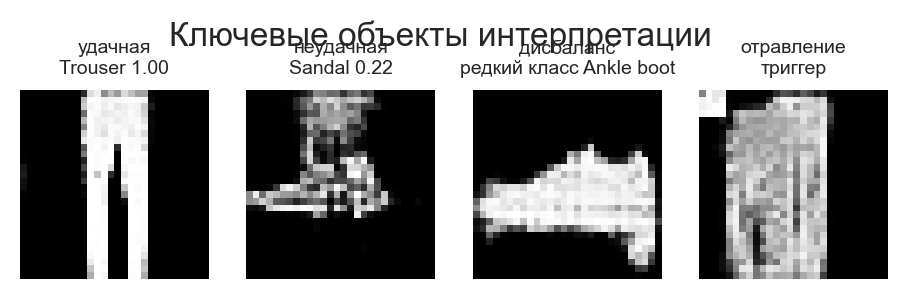

In [7]:
for name in ['part5_interp_baseline', 'part5_latent_sensitivity',
             'part5_dfeatures_umap', 'part5_dfeatures_poison_umap',
             'part5_generator_activations', 'part5_discriminator_filters',
             'part5_sensitivity_trigger', 'part5_weights_discriminator',
             'part5_key_objects']:
    p = FIG / f'{name}.png'
    if p.exists():
        display(Image(str(p)))

Латентное пространство генератора гладко интерполирует между объектами; признаки дискриминатора разделяют реальные и сгенерированные объекты, а триггерные изображения образуют отдельный кластер. Grad-CAM отравленного дискриминатора фокусируется на угловом триггере.

## Выводы

Полные выводы и паспорт модели — в `reports/report.md` и `reports/model_passport.md`. DCGAN моделирует распределение данных через состязательную игру и свёрточную индуктивную гипотезу; он уязвим к дисбалансу (выпадение мод) и отравлению (воспроизведение артефакта), что видно и в метриках, и во внутренних представлениях.